# 03 — Baseline Structural Analysis (Go/No-Go gate, v2)

Loads attribution statistics and evaluates whether the base-model structural
fingerprint shows sufficient variation to justify the LoRA fine-tuning experiment.
Mirrors supervisor's `analyze.py` evaluation.

**Default (v2 two-pod merge):** combines `stats_base_v2.json` (pod 1) with
`stats_base_v2_from160.json` (pod 2 / `02b_baseline_attribution_pod2_from160.ipynb`),
deduplicating by `prompt_id` (prefers `attribution_succeeded` on collision).

**Pilot:** set `USE_PILOT=True` to load only `stats_base.json` (v1 pilot).

**Analysis sections:**
1. Summary table by `(family, label)` — sanity-check dataset balance.
2. Metric distributions by family, label and tail (IQR check).
3. Calibration: logit gap by label.
4. Prune-curve and top-K=20 diagnostics.
5. **Main classifier:** binary T/F subset (`family ∈ {numeric_validity, geometry_claim}`);  
   StandardScaler + LogisticRegression; 5-fold StratifiedKFold **and** leave-one-family-out.
6. **Tail diagnostic:** predict `tail` from structural features (format-detector check).
7. Per-tail facet plots for verdict scatter.
8. **Go/No-Go:** emphasis on IQR spread and protocol readiness (negative T/F classifier result is a valid outcome per supervisor findings).

**No GPU required.** Run locally or on RunPod CPU.

## 0 — Environment Setup

In [2]:
import os
import sys
from pathlib import Path

def _find_repo_root():
    start = Path.cwd().resolve()
    for directory in [start, *start.parents]:
        if (directory / "circuit_tracer" / "__init__.py").is_file():
            return directory
    workspace = Path("/workspace")
    if workspace.is_dir():
        for child in workspace.iterdir():
            if child.is_dir() and (child / "circuit_tracer" / "__init__.py").is_file():
                return child
    repo_override = os.environ.get("CT_REPO_DIR")
    if repo_override:
        override_path = Path(repo_override).expanduser().resolve()
        if (override_path / "circuit_tracer" / "__init__.py").is_file():
            return override_path
    return None

_root = _find_repo_root()
if _root is not None:
    if str(_root) not in sys.path:
        sys.path.insert(0, str(_root))
    _my_work = _root / "my_work"
    if str(_my_work) not in sys.path:
        sys.path.insert(0, str(_my_work))
    print(f"Repo root: {_root}")
else:
    print("WARNING: could not locate circuit_tracer repo.")

MY_WORK = _my_work if _root else Path(".").resolve()

STATISTICS_DIR = MY_WORK / "results" / "statistics"

# Toggle: set USE_PILOT=True to load the v1 pilot stats_base.json only.
USE_PILOT = False

# When USE_PILOT=False: merge pod1 + pod2 shard files (same v2 schema).
USE_MERGE_V2_SHARDS = True
STATS_FILE_POD1 = STATISTICS_DIR / "stats_base_v2.json"
STATS_FILE_POD2 = STATISTICS_DIR / "stats_base_v2_from160.json"  # 02b notebook

if USE_PILOT:
    STATS_FILE = STATISTICS_DIR / "stats_base.json"
    print(f"Stats file (pilot): {STATS_FILE}")
else:
    print(f"Stats pod1       : {STATS_FILE_POD1}")
    print(f"Stats pod2       : {STATS_FILE_POD2}")
    print(f"Merging shards   : {USE_MERGE_V2_SHARDS}")
print(f"Using pilot data: {USE_PILOT}")

Repo root: /workspace/thesis_circuit_breaker
Stats pod1       : /workspace/thesis_circuit_breaker/my_work/results/statistics/stats_base_v2.json
Stats pod2       : /workspace/thesis_circuit_breaker/my_work/results/statistics/stats_base_v2_from160.json
Merging shards   : True
Using pilot data: False


## 1 — Load statistics

In [3]:
import importlib
import json
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110

import utils.graph_statistics as gs_mod
importlib.reload(gs_mod)
from utils.graph_statistics import load_statistics, aggregate_statistics, _flatten_nested, _binary_label_true


def _merge_stats_shards(*lists):
    """Merge stat lists by prompt_id. Prefer succeeded rows; tie-break: later list wins."""
    merged: dict = {}
    for lst in lists:
        for row in lst:
            pid = row.get("prompt_id")
            if pid is None:
                continue
            if pid not in merged:
                merged[pid] = row
            else:
                old, new = merged[pid], row
                old_ok = bool(old.get("attribution_succeeded"))
                new_ok = bool(new.get("attribution_succeeded"))
                if new_ok and not old_ok:
                    merged[pid] = new
                elif old_ok and not new_ok:
                    pass
                else:
                    merged[pid] = new
    return sorted(merged.values(), key=lambda r: str(r.get("prompt_id", "")))


if USE_PILOT:
    all_stats = load_statistics(STATS_FILE)
    print(f"Loaded single file: {len(all_stats)} rows")
elif USE_MERGE_V2_SHARDS:
    _a = load_statistics(STATS_FILE_POD1)
    _b = load_statistics(STATS_FILE_POD2)
    print(f"Pod1 file rows   : {len(_a)}  ({STATS_FILE_POD1.name})")
    print(f"Pod2 file rows   : {len(_b)}  ({STATS_FILE_POD2.name})")
    all_stats = _merge_stats_shards(_a, _b)
    print(f"Merged unique IDs: {len(all_stats)}")
else:
    all_stats = load_statistics(STATS_FILE_POD1)
    print(f"Loaded pod1 only : {len(all_stats)} rows")

stats = [s for s in all_stats if s.get("attribution_succeeded")]
stats_flat = [_flatten_nested(s) for s in stats]

print(f"Total entries  : {len(all_stats)}")
print(f"Succeeded      : {len(stats)}")
print(f"Success rate   : {len(stats)/len(all_stats):.1%}" if all_stats else "")
print()

# ── Summary table by (family, label) — mirrors supervisor analyze.py ──────────
def _label_str(s):
    lbl = s.get("label")
    try:
        return "true" if _binary_label_true(lbl) else "false"
    except Exception:
        return str(lbl)

summary: Counter = Counter()
for s in stats:
    key = (s.get("family", "?"), s.get("tail", "?"), _label_str(s))
    summary[key] += 1

print(f"{'family':<24} {'tail':<20} {'label':<8} {'n':>4}")
print("-" * 62)
for (fam, tail, lbl), cnt in sorted(summary.items()):
    print(f"{fam:<24} {tail:<20} {lbl:<8} {cnt:>4}")
print()

agg = aggregate_statistics(all_stats)

# Core scalar metrics for IQR check and classifier feature set.
# Prune-curve scalars are added dynamically below.
all_scalar_metrics = [
    'n_active_features', 'edge_density', 'mean_top50_score',
    'top10_over_top50', 'layer_entropy', 'mean_error_node_weight', 'logit_gap',
    'layer_stats_mean', 'layer_stats_std', 'layer_stats_median', 'layer_stats_entropy_bits',
    'topk20_score_total', 'topk20_score_gini',
]
# Detect prune-curve scalars from first succeeded row
if stats_flat:
    for _k in sorted(stats_flat[0]):
        if any(_k.startswith(p) for p in (
            "n_kept_at_", "n_edges_at_", "density_at_",
            "n_nodes_total_at_", "n_edges_total_at_",
        )):
            if _k not in all_scalar_metrics:
                all_scalar_metrics.append(_k)

print(f"{'Metric':<36} {'Mean':>10} {'Std':>10} {'Median':>10} {'IQR':>10}")
print("-" * 80)
for m in all_scalar_metrics:
    v = agg.get(m)
    if v:
        print(f"{m:<36} {v['mean']:>10.4f} {v['std']:>10.4f} {v['median']:>10.4f} {v['iqr']:>10.4f}")
    else:
        print(f"{m:<36} {'N/A':>10}")

Pod1 file rows   : 45  (stats_base_v2.json)
Pod2 file rows   : 26  (stats_base_v2_from160.json)
Merged unique IDs: 71
Total entries  : 71
Succeeded      : 71
Success rate   : 100.0%

family                   tail                 label       n
--------------------------------------------------------------
geometry_claim           answer_colon         false       3
geometry_claim           answer_colon         true        3
geometry_claim           the_answer_is        true        1
geometry_claim           true_or_false        false       1
geometry_claim           true_or_false        true        3
numeric_open             answer_colon         true       11
numeric_validity         answer_colon         false       6
numeric_validity         answer_colon         true        8
numeric_validity         the_answer_is        false       7
numeric_validity         the_answer_is        true        5
numeric_validity         true_or_false        false      12
numeric_validity         true_or_f

## 2 — Distribution plots for each metric

Check that distributions are non-collapsed (IQR > 0).

Saved: /workspace/thesis_circuit_breaker/my_work/results/statistics/base_metric_distributions.png


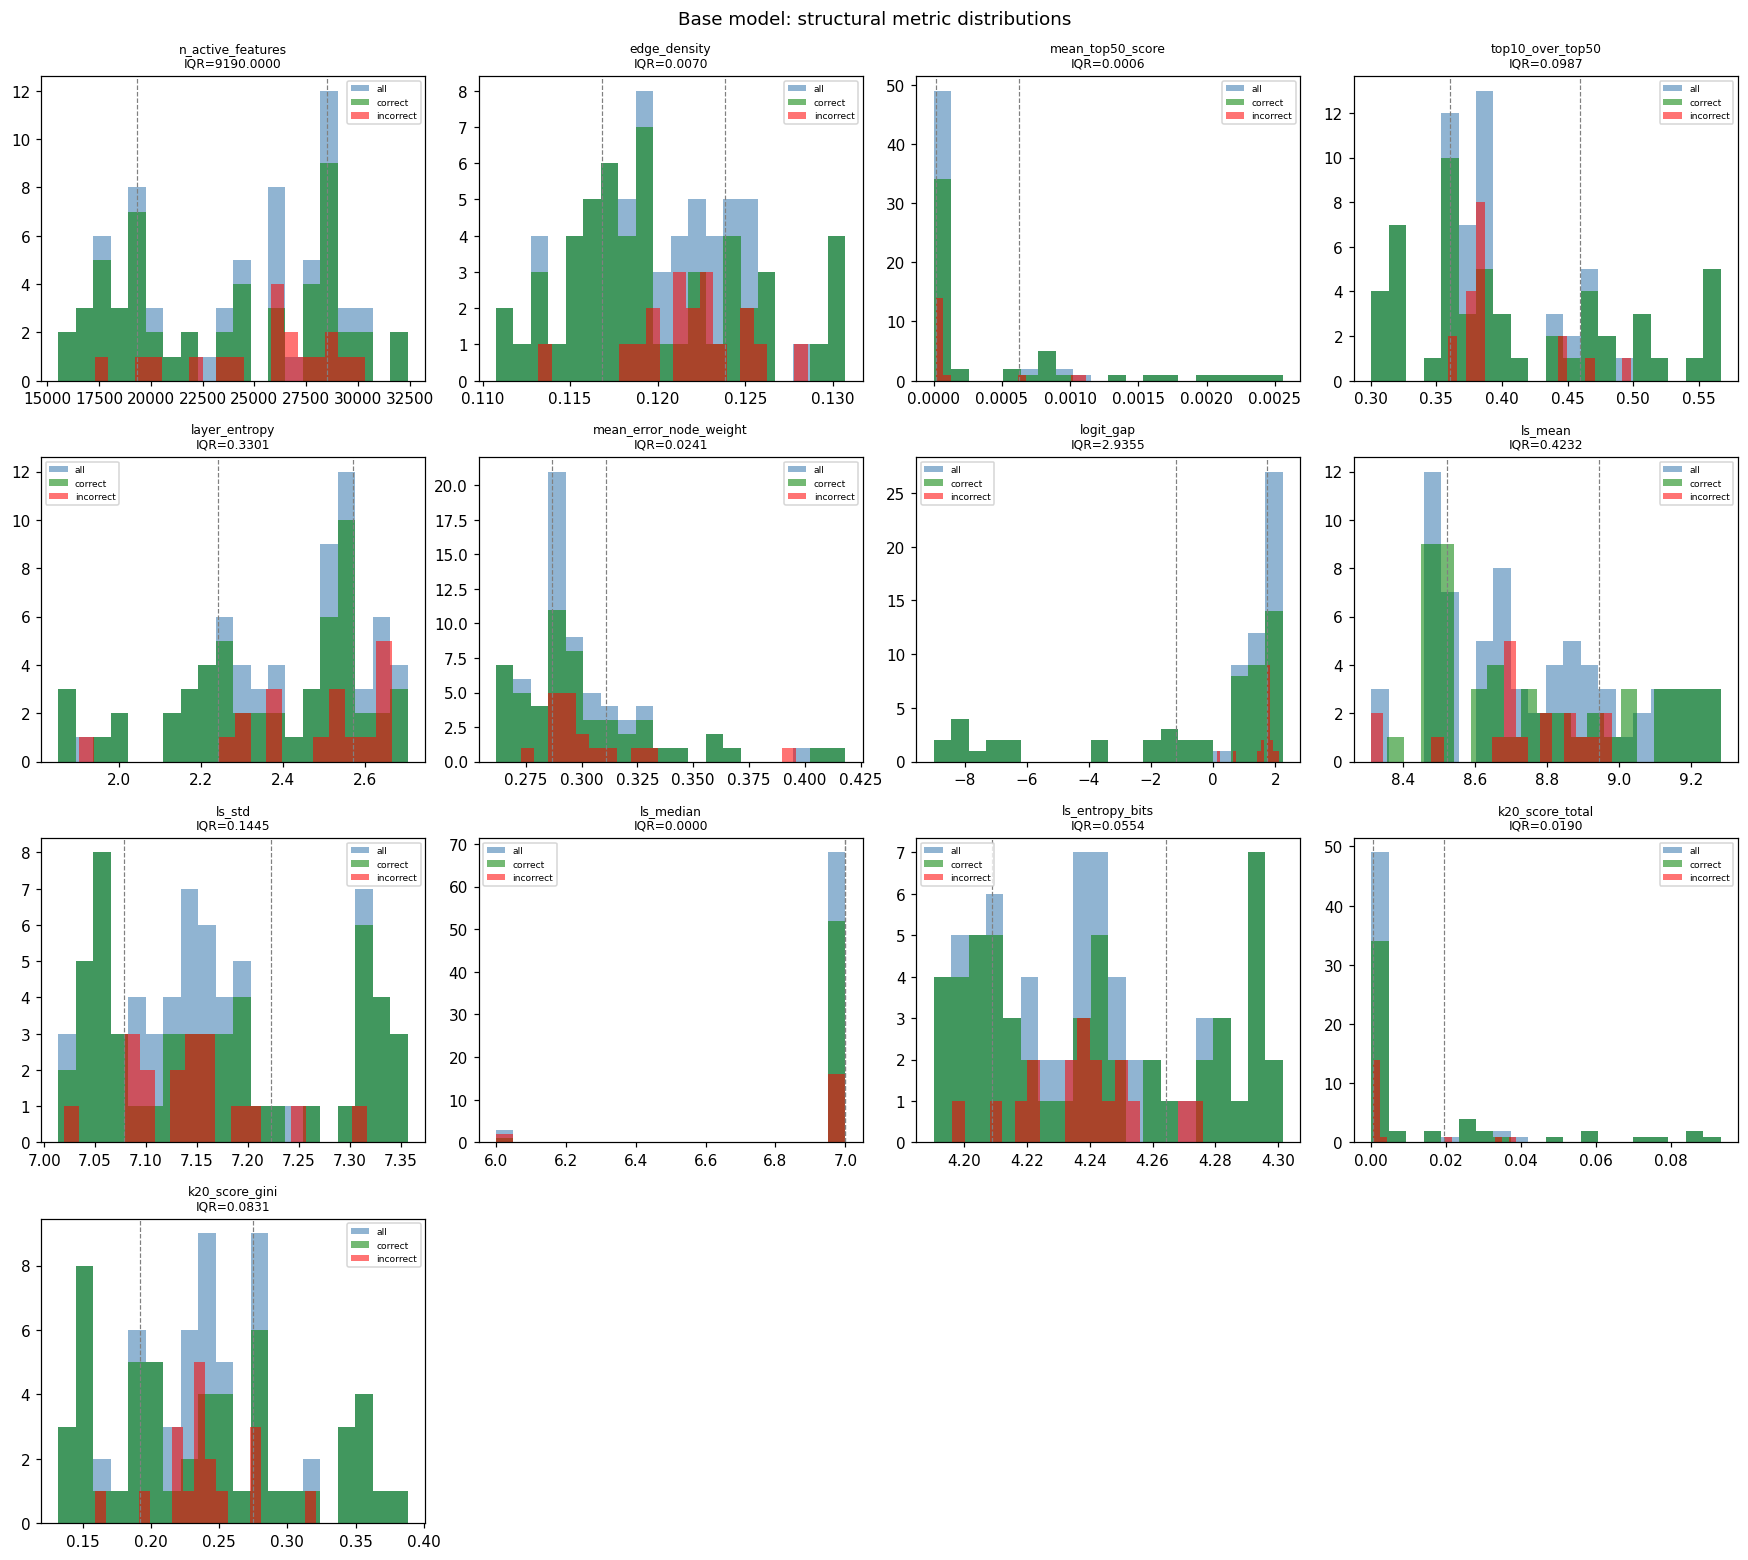

In [4]:
def _is_correct(s):
    """True if the model's argmax first-token matches ground-truth label."""
    if s.get("task_type", "binary") == "binary":
        pt = s.get("prob_true") or 0
        pf = s.get("prob_false") or 0
        try:
            return (pt > pf) == _binary_label_true(s["label"])
        except Exception:
            return False
    else:
        return (s.get("prob_target") or 0) > 0.0

# Core metrics (skip prune curve columns in this overview plot to keep it legible)
plot_metrics = [
    'n_active_features', 'edge_density', 'mean_top50_score',
    'top10_over_top50', 'layer_entropy', 'mean_error_node_weight', 'logit_gap',
    'layer_stats_mean', 'layer_stats_std', 'layer_stats_median', 'layer_stats_entropy_bits',
    'topk20_score_total', 'topk20_score_gini',
]
ncols = 4
nrows = -(-len(plot_metrics) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = axes.flatten()

for ax, metric in zip(axes, plot_metrics):
    pairs = [(sf, s) for sf, s in zip(stats_flat, stats) if sf.get(metric) is not None]
    if not pairs:
        ax.set_title(f"{metric}\n(no data)")
        ax.axis('off')
        continue
    all_vals   = [sf[metric] for sf, _ in pairs]
    corr_vals  = [sf[metric] for sf, s in pairs if _is_correct(s)]
    wrong_vals = [sf[metric] for sf, s in pairs if not _is_correct(s)]
    arr = np.array(all_vals)
    q1, q3 = np.percentile(arr, [25, 75])

    ax.hist(arr, bins=20, alpha=0.6, color='steelblue', label='all')
    if corr_vals:
        ax.hist(corr_vals,  bins=20, alpha=0.55, color='green', label='correct')
    if wrong_vals:
        ax.hist(wrong_vals, bins=20, alpha=0.55, color='red',   label='incorrect')
    ax.axvline(q1, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(q3, color='gray', linestyle='--', linewidth=0.8)
    short = metric.replace('layer_stats_', 'ls_').replace('topk20_', 'k20_')
    ax.set_title(f"{short}\nIQR={q3-q1:.4f}", fontsize=8)
    ax.legend(fontsize=6)

for ax in axes[len(plot_metrics):]:
    ax.axis('off')

plt.tight_layout()
plt.suptitle("Base model: structural metric distributions", y=1.01, fontsize=12)
plot_path = MY_WORK / "results" / "statistics" / "base_metric_distributions.png"
plt.savefig(plot_path, bbox_inches="tight")
print(f"Saved: {plot_path}")
plt.show()

## 3 — Calibration: logit gap distribution by label

Shows whether the base model shows any separation between True and False prompts.

In [14]:
import scipy

ModuleNotFoundError: No module named 'scipy'

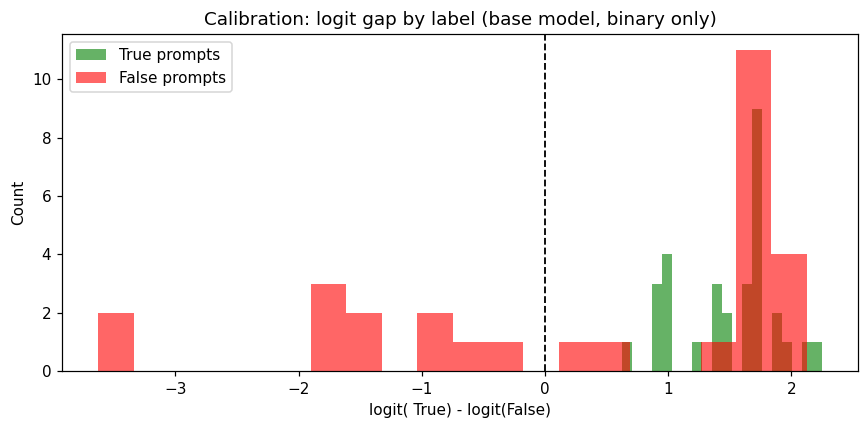

Mann-Whitney U: U=530.0, p=0.2366
No significant logit gap difference by label (expected -- supervisor found ~0.55 accuracy).

First-token accuracy by family:
  geometry_claim          : 7/11 = 63.6%
  numeric_validity        : 35/49 = 71.4%


In [18]:
def _safe_label_true(s):
    try:
        return _binary_label_true(s['label'])
    except Exception:
        return None

binary_stats = [s for s in stats if s.get('task_type', 'binary') == 'binary']
gaps_true  = [s['logit_gap'] for s in binary_stats if s.get('logit_gap') is not None and _safe_label_true(s) is True]
gaps_false = [s['logit_gap'] for s in binary_stats if s.get('logit_gap') is not None and _safe_label_true(s) is False]

fig, ax = plt.subplots(figsize=(8, 4))
if gaps_true:
    ax.hist(gaps_true,  bins=20, alpha=0.6, color='green', label='True prompts')
if gaps_false:
    ax.hist(gaps_false, bins=20, alpha=0.6, color='red',   label='False prompts')
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel("logit( True) - logit(False)")
ax.set_ylabel("Count")
ax.set_title("Calibration: logit gap by label (base model, binary only)")
ax.legend()
plt.tight_layout()
plt.savefig(MY_WORK / "results" / "statistics" / "base_logit_gap.png", bbox_inches="tight")
plt.show()

if gaps_true and gaps_false:
    from scipy import stats as scipy_stats
    stat_val, p_val = scipy_stats.mannwhitneyu(gaps_true, gaps_false, alternative='two-sided')
    print(f"Mann-Whitney U: U={stat_val:.1f}, p={p_val:.4f}")
    if p_val < 0.05:
        print("Statistically significant logit gap difference by label.")
    else:
        print("No significant logit gap difference by label (expected -- supervisor found ~0.55 accuracy).")

print()
print("First-token accuracy by family:")
fam_totals: dict = {}
for s in binary_stats:
    fam = s.get('family', '?')
    correct = _is_correct(s)
    if fam not in fam_totals:
        fam_totals[fam] = [0, 0]
    fam_totals[fam][0] += int(correct)
    fam_totals[fam][1] += 1
for fam, (n_ok, n_total) in sorted(fam_totals.items()):
    print(f"  {fam:<24}: {n_ok}/{n_total} = {n_ok/n_total:.1%}")

## 3b — Prune-curve and top-K=20 diagnostics

Visual checks for the supervisor-requested fingerprint metrics.

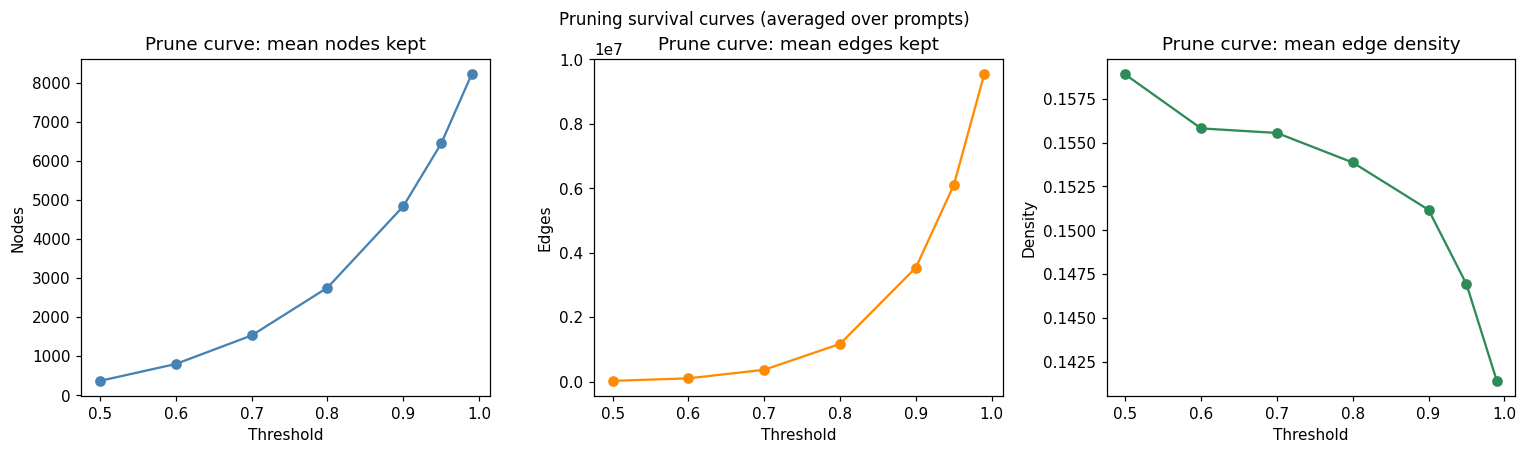

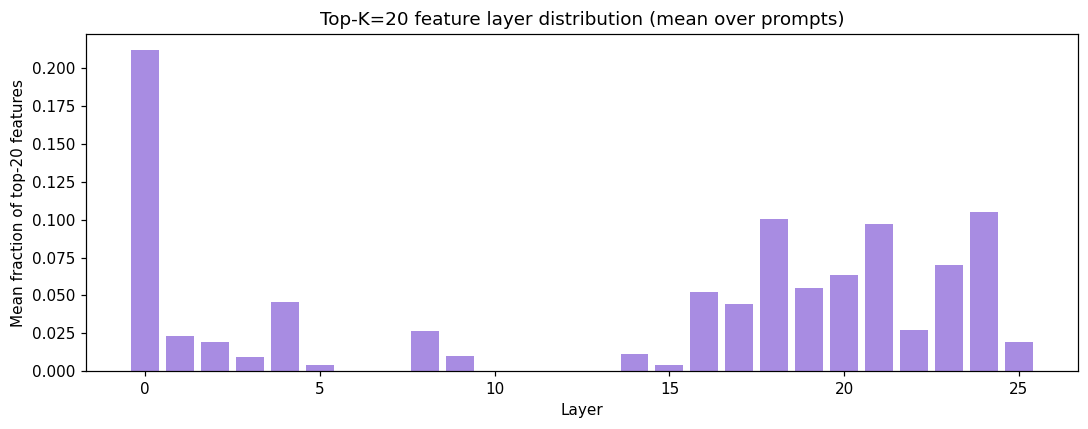

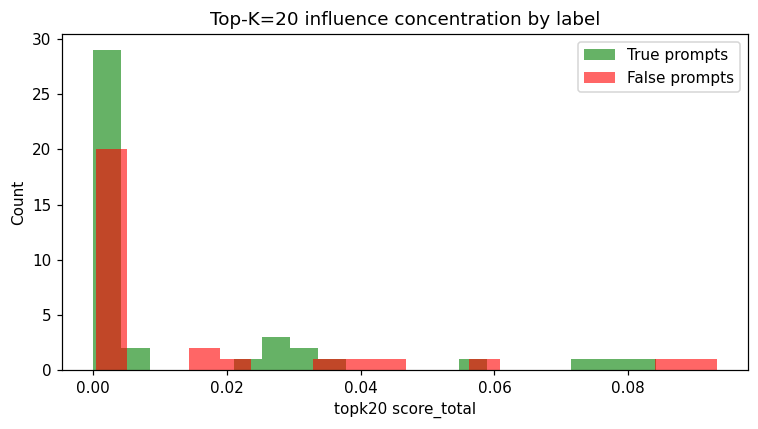

In [19]:
# ── Prune-curve: mean node/edge counts per threshold across all prompts ────────
all_curves = [s.get("prune_curve") for s in stats if s.get("prune_curve")]
if all_curves:
    from collections import defaultdict
    bucket: dict = defaultdict(lambda: {"nodes": [], "edges": [], "density": []})
    for curve in all_curves:
        for pt in curve:
            t = pt["threshold"]
            if pt["n_nodes_kept"] is not None:
                bucket[t]["nodes"].append(pt["n_nodes_kept"])
            if pt["n_edges_kept"] is not None:
                bucket[t]["edges"].append(pt["n_edges_kept"])
            if pt["edge_density"] is not None:
                bucket[t]["density"].append(pt["edge_density"])

    thresholds = sorted(bucket.keys())
    mean_nodes   = [np.mean(bucket[t]["nodes"])   if bucket[t]["nodes"]   else np.nan for t in thresholds]
    mean_edges   = [np.mean(bucket[t]["edges"])   if bucket[t]["edges"]   else np.nan for t in thresholds]
    mean_density = [np.mean(bucket[t]["density"]) if bucket[t]["density"] else np.nan for t in thresholds]

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))
    ax1.plot(thresholds, mean_nodes,   marker='o', color='steelblue')
    ax1.set_title("Prune curve: mean nodes kept"); ax1.set_xlabel("Threshold"); ax1.set_ylabel("Nodes")
    ax2.plot(thresholds, mean_edges,   marker='o', color='darkorange')
    ax2.set_title("Prune curve: mean edges kept"); ax2.set_xlabel("Threshold"); ax2.set_ylabel("Edges")
    ax3.plot(thresholds, mean_density, marker='o', color='seagreen')
    ax3.set_title("Prune curve: mean edge density"); ax3.set_xlabel("Threshold"); ax3.set_ylabel("Density")
    plt.tight_layout()
    plt.suptitle("Pruning survival curves (averaged over prompts)", y=1.02, fontsize=11)
    plt.savefig(MY_WORK / "results" / "statistics" / "base_prune_curves.png", bbox_inches="tight")
    plt.show()
else:
    print("No prune_curve data found in stats — was 02 run with the updated graph_statistics.py?")

# ── Top-K=20 layer histogram: mean distribution across prompts ─────────────────
from utils.graph_statistics import N_LAYERS
layer_hists = [s["topk20"]["layer_hist"] for s in stats if s.get("topk20")]
if layer_hists:
    mean_lh = np.mean(np.array(layer_hists), axis=0)  # shape (26,)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(range(N_LAYERS), mean_lh, color='mediumpurple', alpha=0.8)
    ax.set_xlabel("Layer"); ax.set_ylabel("Mean fraction of top-20 features")
    ax.set_title("Top-K=20 feature layer distribution (mean over prompts)")
    plt.tight_layout()
    plt.savefig(MY_WORK / "results" / "statistics" / "base_topk20_layer_hist.png", bbox_inches="tight")
    plt.show()

    # score_total distribution by label
    totals_true  = [s["topk20"]["score_total"] for s in stats if s.get("topk20") and s["label"]]
    totals_false = [s["topk20"]["score_total"] for s in stats if s.get("topk20") and not s["label"]]
    fig, ax = plt.subplots(figsize=(7, 4))
    if totals_true:
        ax.hist(totals_true,  bins=20, alpha=0.6, color='green', label='True prompts')
    if totals_false:
        ax.hist(totals_false, bins=20, alpha=0.6, color='red',   label='False prompts')
    ax.set_xlabel("topk20 score_total"); ax.set_ylabel("Count")
    ax.set_title("Top-K=20 influence concentration by label")
    ax.legend()
    plt.tight_layout()
    plt.savefig(MY_WORK / "results" / "statistics" / "base_topk20_score_by_label.png", bbox_inches="tight")
    plt.show()
else:
    print("No topk20 data found.")

## 4 — Main classifier: binary True/False from structural metrics

Supervisor-aligned evaluation:
- **Subset:** rows with `task_type == "binary"` and `family in {numeric_validity, geometry_claim}`.
- **Target:** predict True/False label (not "correct/incorrect") from structural features.
- **Method:** StandardScaler + LogisticRegression; 5-fold StratifiedKFold **and** leave-one-family-out.
- Features include all `_flatten_nested` scalars: legacy + prune-curve + layer_stats + topk20.

Note: supervisor found ~0.55 accuracy, suggesting the fingerprint is a *format detector*
rather than a *correctness detector*. A weak result is informative, not a pipeline failure.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, LeaveOneGroupOut

# ── Feature columns: all flattened scalars present in the data ────────────────
base_feature_cols = [
    'n_active_features', 'edge_density', 'mean_top50_score',
    'top10_over_top50', 'layer_entropy', 'mean_error_node_weight',
    'layer_stats_mean', 'layer_stats_std', 'layer_stats_median', 'layer_stats_entropy_bits',
    'topk20_score_total', 'topk20_score_gini',
]
# Add prune-curve scalars if present
_prune_prefixes = ('density_at_', 'n_kept_at_', 'n_edges_at_', 'n_nodes_total_at_', 'n_edges_total_at_')
prune_cols = sorted([k for k in (stats_flat[0] if stats_flat else {}) if k.startswith(_prune_prefixes)])
feature_cols = base_feature_cols + prune_cols

# ── Filter to binary T/F families ─────────────────────────────────────────────
TF_FAMILIES = {'numeric_validity', 'geometry_claim'}
clf_stats  = [s for s in stats if s.get('task_type', 'binary') == 'binary' and s.get('family') in TF_FAMILIES]
clf_flat   = [_flatten_nested(s) for s in clf_stats]

rows, labels, families = [], [], []
for sf, s in zip(clf_flat, clf_stats):
    row = [sf.get(c) for c in feature_cols]
    if any(v is None for v in row):
        continue
    try:
        lbl = int(_binary_label_true(s['label']))
    except Exception:
        continue
    rows.append(row)
    labels.append(lbl)
    families.append(s.get('family', '?'))

if not rows:
    print("No complete rows. Run 02 with updated graph_statistics.py first.")
    logreg_beats_majority = False
else:
    X = np.array(rows)
    y = np.array(labels, dtype=int)
    groups = np.array(families)
    majority_acc = max(y.mean(), 1 - y.mean())

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=500, C=1.0)),
    ])

    # 5-fold stratified CV
    cv5 = StratifiedKFold(n_splits=min(5, int(y.mean() * len(y)), len(y) - 1), shuffle=True, random_state=42)
    cv5_scores = cross_val_score(pipe, X, y, cv=cv5, scoring='accuracy')

    # Leave-one-family-out
    loo = LeaveOneGroupOut()
    loo_scores = []
    loo_details = []
    for train_idx, test_idx in loo.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        held_fam = groups[test_idx][0]
        # Guard: both classes must be present in train set
        if len(np.unique(y_tr)) < 2:
            loo_details.append((held_fam, None, "skipped: single class in train"))
            continue
        p = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=500, C=1.0))])
        p.fit(X_tr, y_tr)
        acc = p.score(X_te, y_te)
        loo_scores.append(acc)
        loo_details.append((held_fam, acc, f"n_test={len(y_te)}"))

    print(f"Feature matrix      : {X.shape} ({len(feature_cols)} features, {len(rows)} rows)")
    print(f"Class balance       : {y.mean():.1%} True, {1-y.mean():.1%} False")
    print(f"Majority baseline   : {majority_acc:.1%}")
    print(f"5-fold CV accuracy  : {cv5_scores.mean():.1%} +/- {cv5_scores.std():.1%}")
    print()
    print("Leave-one-family-out:")
    for fam, acc, note in loo_details:
        acc_str = f"{acc:.1%}" if acc is not None else "N/A"
        print(f"  held-out={fam:<22}  acc={acc_str}  ({note})")
    if loo_scores:
        print(f"  Mean LOO accuracy : {np.mean(loo_scores):.1%}")
    print()

    pipe.fit(X, y)
    coefs = pipe.named_steps['clf'].coef_[0]
    print("Top feature coefficients (|coef| ranked):")
    for feat, coef in sorted(zip(feature_cols, coefs), key=lambda x: -abs(x[1]))[:15]:
        print(f"  {feat:<36} {coef:>+.4f}")

    logreg_beats_majority = bool(cv5_scores.mean() > majority_acc)
    print()
    print(f"Classifier > majority baseline: {logreg_beats_majority}")
    print("(A result near 0.50 is expected and informative -- see Go/No-Go cell.)")

Feature matrix      : (60, 47) (47 features, 60 rows)
Class balance       : 51.7% True, 48.3% False
Majority baseline   : 51.7%
5-fold CV accuracy  : 71.7% +/- 4.1%

Leave-one-family-out:
  held-out=geometry_claim          acc=54.5%  (n_test=11)
  held-out=numeric_validity        acc=53.1%  (n_test=49)
  Mean LOO accuracy : 53.8%

Top feature coefficients (|coef| ranked):
  layer_stats_std                      +0.9439
  layer_stats_median                   +0.6357
  top10_over_top50                     +0.6306
  mean_top50_score                     -0.6201
  density_at_0.80                      -0.5579
  edge_density                         -0.5480
  layer_stats_mean                     -0.5474
  density_at_0.70                      -0.4704
  n_edges_at_0.90                      -0.4482
  layer_stats_entropy_bits             -0.4222
  topk20_score_total                   -0.4020
  n_edges_at_0.80                      -0.3977
  layer_entropy                        +0.3405
  topk20_score

## 5 — Tail diagnostic: can the fingerprint predict the prompt tail?

If structural features predict *which tail variant was used*, that confirms the fingerprint
captures format/template information (supervisor's "format detector" finding). A high accuracy
here is a meaningful positive result — it means the graph captures something real, even if it
cannot predict T/F correctness.

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Use the same binary T/F family subset
tail_stats = [s for s in stats if s.get('task_type', 'binary') == 'binary' and s.get('family') in TF_FAMILIES and s.get('tail')]
tail_flat  = [_flatten_nested(s) for s in tail_stats]

tail_rows, tail_labels = [], []
for sf, s in zip(tail_flat, tail_stats):
    row = [sf.get(c) for c in feature_cols]
    if any(v is None for v in row):
        continue
    tail_rows.append(row)
    tail_labels.append(s['tail'])

if not tail_rows or len(set(tail_labels)) < 2:
    print("Not enough tail variety in the data for tail diagnostic.")
    tail_acc = None
else:
    X_t = np.array(tail_rows)
    le = LabelEncoder()
    y_t = le.fit_transform(tail_labels)

    pipe_t = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=500, C=1.0)),
    ])
    n_splits = min(5, min(np.bincount(y_t)))
    if n_splits < 2:
        print(f"Too few samples per tail class for CV (min class size = {min(np.bincount(y_t))}).")
        tail_acc = None
    else:
        cv_t = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        tail_cv_scores = cross_val_score(pipe_t, X_t, y_t, cv=cv_t, scoring='accuracy')
        tail_majority = max(np.bincount(y_t)) / len(y_t)

        print(f"Tail classes         : {le.classes_}")
        print(f"Class counts         : {np.bincount(y_t)}")
        print(f"Tail majority base   : {tail_majority:.1%}")
        print(f"CV accuracy (tail)   : {tail_cv_scores.mean():.1%} +/- {tail_cv_scores.std():.1%}")

        tail_acc = tail_cv_scores.mean()
        pipe_t.fit(X_t, y_t)
        coefs_t = pipe_t.named_steps['clf'].coef_
        print()
        print("Most discriminative features per tail class:")
        for cls_idx, cls_name in enumerate(le.classes_):
            top = sorted(zip(feature_cols, coefs_t[cls_idx]), key=lambda x: -abs(x[1]))[:5]
            top_str = ", ".join(f"{f}({c:+.2f})" for f, c in top)
            print(f"  {cls_name}: {top_str}")
        print()
        if tail_cv_scores.mean() > tail_majority:
            print("RESULT: Fingerprint does predict tail variant -- format detector confirmed.")
        else:
            print("RESULT: Fingerprint does NOT predict tail -- no strong format-detection signal.")

Tail classes         : ['answer_colon' 'the_answer_is' 'true_or_false']
Class counts         : [20 13 27]
Tail majority base   : 45.0%
CV accuracy (tail)   : 96.7% +/- 4.1%

Most discriminative features per tail class:
  answer_colon: mean_top50_score(+0.78), topk20_score_total(+0.70), layer_entropy(-0.37), topk20_score_gini(+0.34), top10_over_top50(+0.29)
  the_answer_is: mean_top50_score(-0.72), topk20_score_total(-0.64), density_at_0.50(-0.46), layer_stats_std(+0.34), topk20_score_gini(-0.29)
  true_or_false: layer_entropy(+0.38), density_at_0.50(+0.33), n_edges_at_0.50(+0.18), layer_stats_mean(-0.16), n_edges_total_at_0.50(+0.16)

RESULT: Fingerprint does predict tail variant -- format detector confirmed.


## 6 — Per-tail facet plots: verdict scatter and key metrics

Shows whether the logit gap and key structural metrics vary by tail, enabling a visual
check of the format-detector hypothesis.

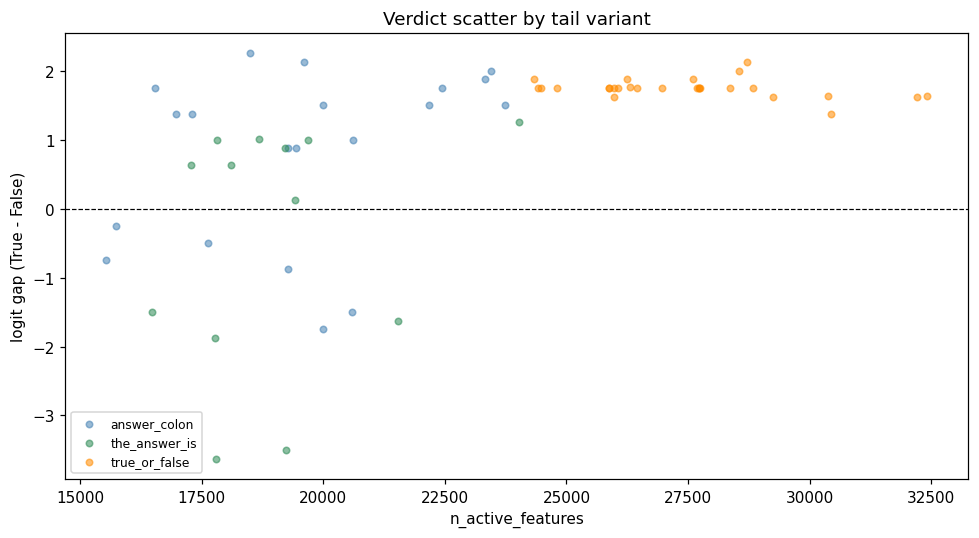

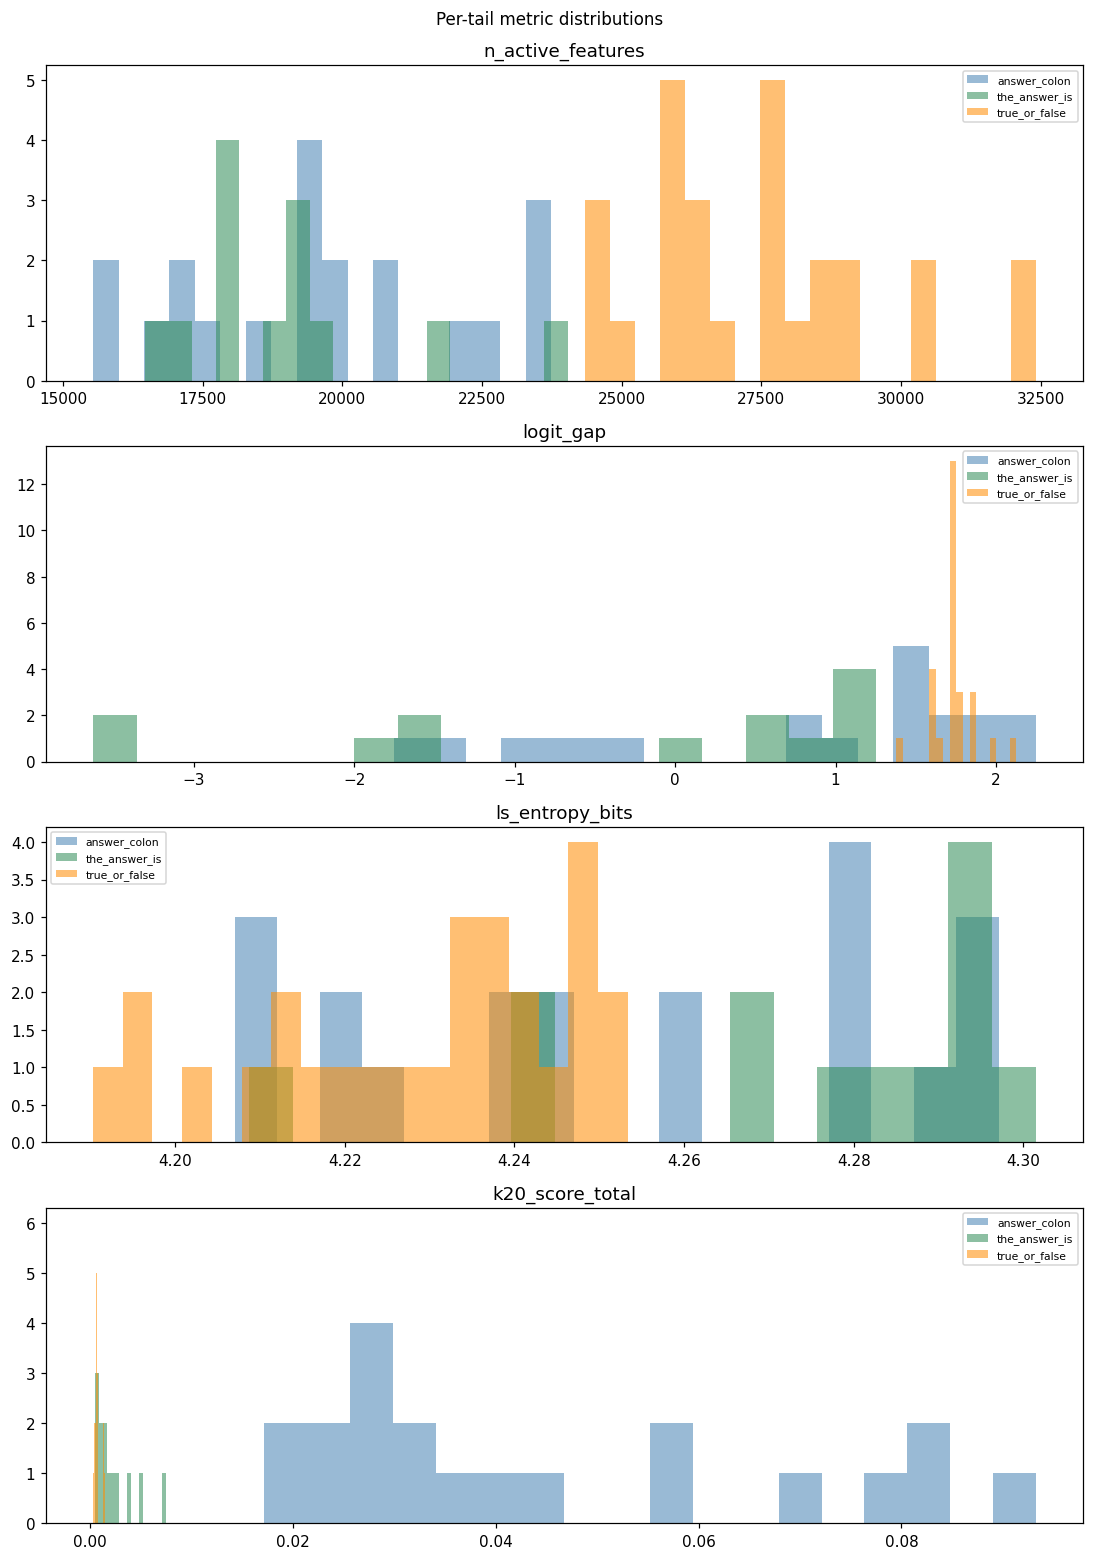

In [24]:
TAILS_ORDER = ['answer_colon', 'true_or_false', 'the_answer_is']
TAIL_COLORS = {'answer_colon': 'steelblue', 'true_or_false': 'darkorange', 'the_answer_is': 'seagreen'}

facet_stats = [s for s in binary_stats if s.get('tail')]
facet_flat  = [_flatten_nested(s) for s in facet_stats]
tails_present = sorted(set(s.get('tail') for s in facet_stats))

# ── Verdict scatter: logit gap vs. n_active_features, coloured by tail ────────
fig, ax = plt.subplots(figsize=(9, 5))
for tail in tails_present:
    xs = [sf.get('n_active_features') for sf, s in zip(facet_flat, facet_stats) if s.get('tail') == tail and sf.get('n_active_features') is not None]
    ys = [s.get('logit_gap') for s in facet_stats if s.get('tail') == tail and s.get('logit_gap') is not None]
    if xs and ys and len(xs) == len(ys):
        ax.scatter(xs, ys, alpha=0.55, s=18, label=tail, color=TAIL_COLORS.get(tail, 'gray'))
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel("n_active_features")
ax.set_ylabel("logit gap (True - False)")
ax.set_title("Verdict scatter by tail variant")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(MY_WORK / "results" / "statistics" / "base_verdict_scatter_by_tail.png", bbox_inches="tight")
plt.show()

# ── Per-tail distribution of key metrics ─────────────────────────────────────
facet_metrics = ['n_active_features', 'logit_gap', 'layer_stats_entropy_bits', 'topk20_score_total']
fig, axes = plt.subplots(len(facet_metrics), 1, figsize=(10, 3.5 * len(facet_metrics)))
for ax, metric in zip(axes, facet_metrics):
    for tail in tails_present:
        vals = [sf.get(metric) for sf, s in zip(facet_flat, facet_stats) if s.get('tail') == tail and sf.get(metric) is not None]
        if vals:
            ax.hist(vals, bins=18, alpha=0.55, label=tail, color=TAIL_COLORS.get(tail, 'gray'))
    ax.set_title(metric.replace('layer_stats_', 'ls_').replace('topk20_', 'k20_'))
    ax.legend(fontsize=7)
plt.tight_layout()
plt.suptitle("Per-tail metric distributions", y=1.01, fontsize=11)
plt.savefig(MY_WORK / "results" / "statistics" / "base_per_tail_metrics.png", bbox_inches="tight")
plt.show()

## 7 — IQR spread check (Condition 1 of Go/No-Go)

In [25]:
# Check IQR spread for all superset scalar metrics (Condition 1 of Go/No-Go)
iqr_metrics = all_scalar_metrics  # defined in cell 4

non_trivial = []
print(f"{'Metric':<36} {'IQR':>12}  Status")
print("-" * 56)
for m in iqr_metrics:
    vals = [sf.get(m) for sf in stats_flat if sf.get(m) is not None]
    if vals:
        arr = np.array(vals, dtype=float)
        q1, q3 = np.percentile(arr, [25, 75])
        iqr = q3 - q1
        status = "OK" if iqr > 0 else "COLLAPSED"
        print(f"  {m:<34} {iqr:>12.6f}  [{status}]")
        if iqr > 0:
            non_trivial.append(m)
    else:
        print(f"  {m:<34} {'N/A':>12}  [NO DATA]")

print()
print(f"Metrics with IQR > 0: {len(non_trivial)}/{len(iqr_metrics)}")
condition1 = len(non_trivial) >= 2
print(f"Condition 1 (>=2 non-trivial metrics): {'PASS' if condition1 else 'FAIL'}")

Metric                                        IQR  Status
--------------------------------------------------------
  n_active_features                   9190.000000  [OK]
  edge_density                           0.007016  [OK]
  mean_top50_score                       0.000611  [OK]
  top10_over_top50                       0.098652  [OK]
  layer_entropy                          0.330146  [OK]
  mean_error_node_weight                 0.024145  [OK]
  logit_gap                              2.935544  [OK]
  layer_stats_mean                       0.423199  [OK]
  layer_stats_std                        0.144487  [OK]
  layer_stats_median                     0.000000  [COLLAPSED]
  layer_stats_entropy_bits               0.055368  [OK]
  topk20_score_total                     0.018974  [OK]
  topk20_score_gini                      0.083054  [OK]
  density_at_0.50                        0.021043  [OK]
  density_at_0.60                        0.007976  [OK]
  density_at_0.70                     

## 8 — GO / STOP decision (revised criteria)

In [26]:
condition1 = len(non_trivial) >= 2  # set in section 7
condition2_logreg = logreg_beats_majority if 'logreg_beats_majority' in dir() else False
condition2_tail   = (tail_acc is not None and tail_acc > 0.5) if 'tail_acc' in dir() else False

print("=" * 70)
print("GO / NO-GO DECISION (v2 revised criteria)")
print("=" * 70)
print()
print(f"Condition 1 — >=2 metrics with IQR > 0           : {'PASS' if condition1 else 'FAIL'}")
print(f"             (non-trivial metrics: {len(non_trivial)}/{len(all_scalar_metrics)})")
print()
print(f"Classifier signal (T/F, 5-fold CV > majority)     : {'YES' if condition2_logreg else 'NO'}")
print(f"Format signal     (tail, CV > majority)           : {'YES' if condition2_tail   else 'NO'}")
print()
print("Interpretation:")
print("  - Condition 1 is the primary gate: the pipeline must produce non-collapsed")
print("    distributions. A collapsed distribution means attribution failed silently.")
print("  - A WEAK T/F classifier result is expected and NOT a failure: supervisor found")
print("    ~0.55 accuracy, interpreted as the fingerprint being a FORMAT detector.")
print("  - If the TAIL classifier is strong, that confirms structural signal exists;")
print("    it is just format-level, not correctness-level.")
print()

if not condition1:
    print("DECISION: STOP")
    print("  No meaningful structural variation found. Check attribution pipeline.")
elif condition2_tail:
    print("DECISION: GO (format detector confirmed)")
    print("  Structural fingerprint varies non-trivially and encodes prompt tail.")
    print("  This replicates the supervisor's finding. Proceed with LoRA analysis.")
    print("  Thesis framing: 'base-model circuit is a format detector; does fine-tuning")
    print("  shift it toward content-sensitivity?'")
else:
    print("DECISION: CONDITIONAL GO")
    print("  Structural variation exists (Condition 1 passes).")
    print("  No strong format- or correctness-detection signal yet.")
    print("  May need more prompts or should inspect feature distributions manually.")
    print("  Proceed with LoRA but note the weaker baseline signal in the thesis.")

GO / NO-GO DECISION (v2 revised criteria)

Condition 1 — >=2 metrics with IQR > 0           : PASS
             (non-trivial metrics: 47/48)

Classifier signal (T/F, 5-fold CV > majority)     : YES
Format signal     (tail, CV > majority)           : YES

Interpretation:
  - Condition 1 is the primary gate: the pipeline must produce non-collapsed
    distributions. A collapsed distribution means attribution failed silently.
  - A WEAK T/F classifier result is expected and NOT a failure: supervisor found
    ~0.55 accuracy, interpreted as the fingerprint being a FORMAT detector.
  - If the TAIL classifier is strong, that confirms structural signal exists;
    it is just format-level, not correctness-level.

DECISION: GO (format detector confirmed)
  Structural fingerprint varies non-trivially and encodes prompt tail.
  This replicates the supervisor's finding. Proceed with LoRA analysis.
  Thesis framing: 'base-model circuit is a format detector; does fine-tuning
  shift it toward conten